#**Telecom_X - Análisis de Evasión de Clientes - Parte 2**

##**EXTRACCIÓN DEL ARCHIVO**

In [126]:
import pandas as pd

In [127]:
url = ('https://raw.githubusercontent.com/Karol-Caicedo/CHALLENGE_TELECOM-X_2/main/datos_tratados%20(1).csv')

In [128]:
df = pd.read_csv(url)

In [129]:
df.head()

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges.monthly,charges.total,cuentas_diarias
0,0002-ORFBO,No,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [130]:
df["churn"] = (df["churn"] == "Yes").astype(int)

In [131]:
df["gender"].unique()

array(['Female', 'Male'], dtype=object)

In [132]:
df["gender"] = df["gender"].map({
   'Female' : 0,
    'Male': 1
})

##**Eliminación de Columnas Irrelevantes**

In [133]:
nuevo_df = df[[
    "churn",
    "gender",
    "tenure",
    "contract",
    "paymentmethod",
    "charges.total",
]]

In [134]:
nuevo_df.head()

,churn,gender,tenure,contract,paymentmethod,charges.total
0,0,0,9,One year,Mailed check,593.30
1,0,1,9,Month-to-month,Mailed check,542.40
2,1,1,4,Month-to-month,Electronic check,280.85
3,1,1,13,Month-to-month,Electronic check,1237.85
4,1,0,3,Month-to-month,Mailed check,267.40


##**Encoding**

In [135]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [136]:
columnas = nuevo_df.columns

In [137]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['contract', 'paymentmethod']
),
    remainder = 'passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False)

In [138]:
X = one_hot.fit_transform(nuevo_df)

In [139]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__contract_Month-to-month',
       'onehotencoder__contract_One year',
       'onehotencoder__contract_Two year',
       'onehotencoder__paymentmethod_Bank transfer (automatic)',
       'onehotencoder__paymentmethod_Credit card (automatic)',
       'onehotencoder__paymentmethod_Electronic check',
       'onehotencoder__paymentmethod_Mailed check', 'remainder__churn',
       'remainder__gender', 'remainder__tenure',
       'remainder__charges.total'], dtype=object)

In [140]:
encondig = pd.DataFrame(X, columns = one_hot.get_feature_names_out(columnas))

In [141]:
encondig.head()

,onehotencoder__contract_Month-to-month,onehotencoder__contract_One year,onehotencoder__contract_Two year,onehotencoder__paymentmethod_Bank transfer (automatic),onehotencoder__paymentmethod_Credit card (automatic),onehotencoder__paymentmethod_Electronic check,onehotencoder__paymentmethod_Mailed check,remainder__churn,remainder__gender,remainder__tenure,remainder__charges.total
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9.0,593.30
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,9.0,542.40
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,4.0,280.85
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,13.0,1237.85
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,3.0,267.40


##**Análisis de Correlación**

In [142]:
correlacion = encondig.corr()
correlacion

,onehotencoder__contract_Month-to-month,onehotencoder__contract_One year,onehotencoder__contract_Two year,onehotencoder__paymentmethod_Bank transfer (automatic),onehotencoder__paymentmethod_Credit card (automatic),onehotencoder__paymentmethod_Electronic check,onehotencoder__paymentmethod_Mailed check,remainder__churn,remainder__gender,remainder__tenure,remainder__charges.total
onehotencoder__contract_Month-to-month,1.000000,-0.569613,-0.622417,-0.179206,-0.206587,0.332300,0.004860,0.395584,-0.001312,-0.647138,-0.444708
onehotencoder__contract_One year,-0.569613,1.000000,-0.288764,0.056377,0.070132,-0.108921,-0.001635,-0.173958,0.007328,0.205970,0.175271
onehotencoder__contract_Two year,-0.622417,-0.288764,1.000000,0.155061,0.173856,-0.283355,-0.004105,-0.295138,-0.005449,0.557675,0.351109
onehotencoder__paymentmethod_Bank transfer (automatic),-0.179206,0.056377,0.155061,1.000000,-0.277484,-0.376695,-0.288403,-0.114767,-0.018361,0.240732,0.180759
onehotencoder__paymentmethod_Credit card (automatic),-0.206587,0.070132,0.173856,-0.277484,1.000000,-0.373508,-0.285963,-0.131085,0.000700,0.235319,0.185229
onehotencoder__paymentmethod_Electronic check,0.332300,-0.108921,-0.283355,-0.376695,-0.373508,1.000000,-0.388205,0.294626,0.002060,-0.207056,-0.056029
onehotencoder__paymentmethod_Mailed check,0.004860,-0.001635,-0.004105,-0.288403,-0.285963,-0.388205,1.000000,-0.090061,0.015057,-0.234305,-0.296090
remainder__churn,0.395584,-0.173958,-0.295138,-0.114767,-0.131085,0.294626,-0.090061,1.000000,-0.009555,-0.344079,-0.193345
remainder__gender,-0.001312,0.007328,-0.005449,-0.018361,0.000700,0.002060,0.015057,-0.009555,1.000000,0.005765,0.000367
remainder__tenure,-0.647138,0.205970,0.557675,0.240732,0.235319,-0.207056,-0.234305,-0.344079,0.005765,1.000000,0.825407


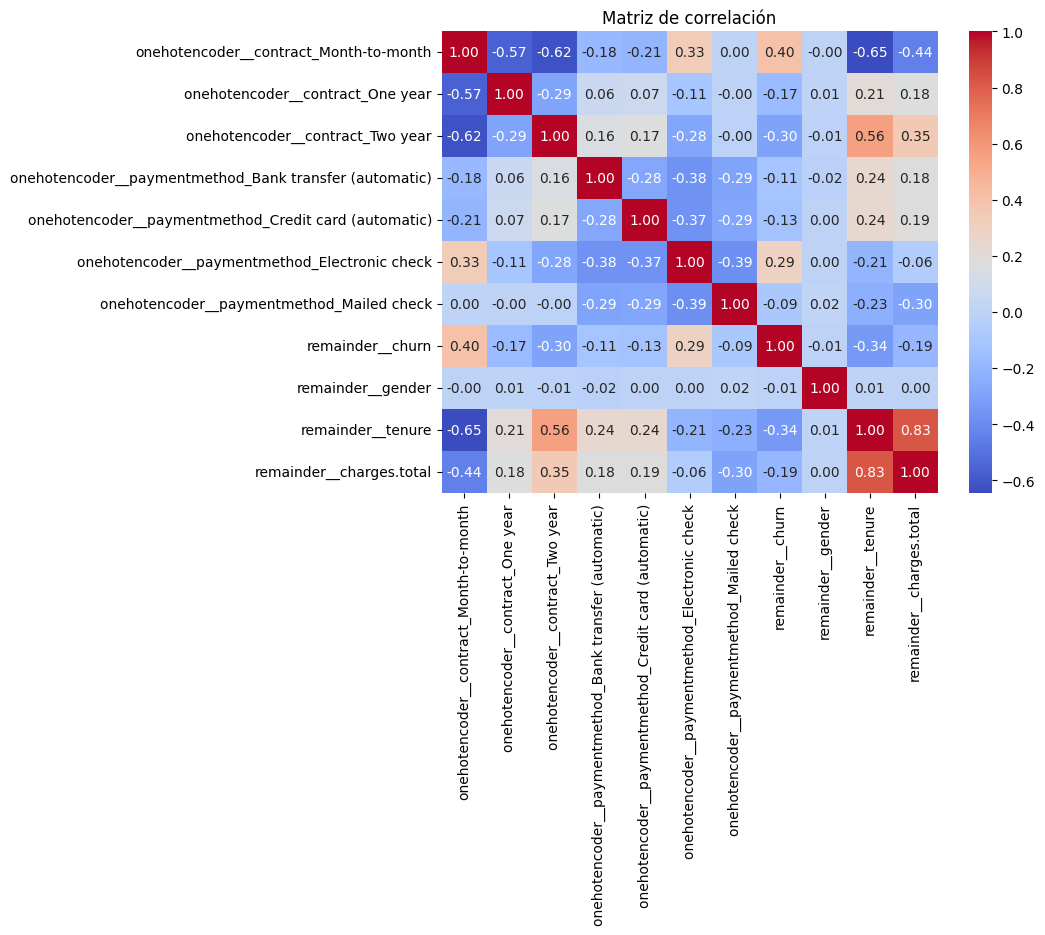

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

Las variables con mayor correlación absoluta con churn son:

1. contract_Month-to-month

2. tenure

3. contract_Two year

4. paymentmethod_Electronic check

##**Verificación de la Proporción de Cancelación (Churn)**

In [144]:
df["churn"].value_counts()

,count
churn,
0,5398
1,1869


In [145]:
df["churn"].value_counts(normalize=True) * 100

,proportion
churn,
0,74.280996
1,25.719004


##**Análisis Dirigido**

###**Tiempo de contrato x Cancelación**

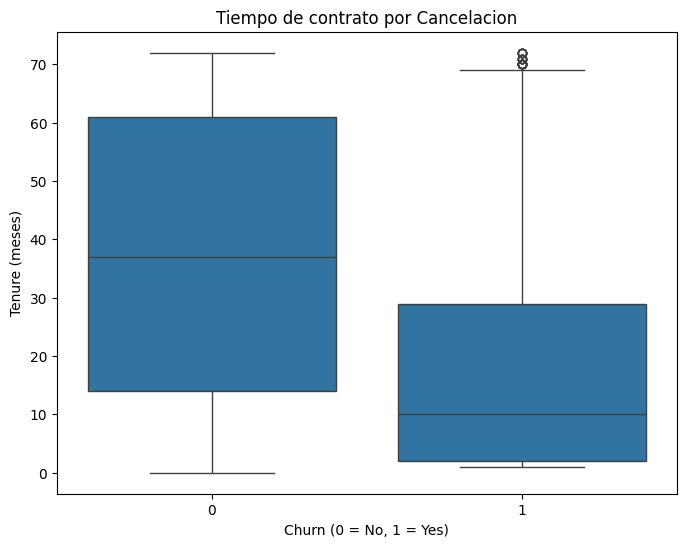

In [146]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(
    x="churn",
    y="tenure",
    data=nuevo_df
)
plt.title("Tiempo de contrato por Cancelacion")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure (meses)")
plt.show()

###**Gasto total x Cancelación**

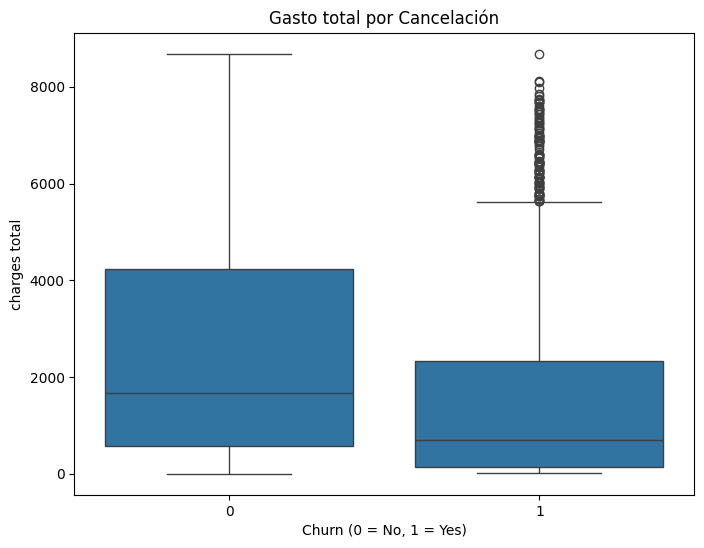

In [147]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="churn",
    y="charges.total",
    data=nuevo_df
)

plt.title("Gasto total por Cancelación")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("charges total")
plt.show()

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

##**Separación de Datos**

In [148]:
X = encondig.drop("remainder__churn", axis=1)
y = encondig["remainder__churn"]

In [149]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

##**Creación de Modelos**

###**KNN**

In [150]:
from sklearn.neighbors import KNeighborsClassifier

In [151]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_knn.fit(X_train_scaled, y_train)

y_pred_knn = modelo_knn.predict(X_test_scaled)

###**RANDOM FOREST**

In [152]:
from sklearn.ensemble import RandomForestClassifier

In [153]:
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

##**Evaluación de los Modelos**



In [154]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluar_modelo(nombre, y_test, y_pred):
    print(f"\nModelo: {nombre}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))
    print("Matriz de Confusión:\n", confusion_matrix(y_test, y_pred))

In [155]:
evaluar_modelo("KNN", y_test, y_pred_knn)
evaluar_modelo("Random Forest", y_test, y_pred_rf)


Modelo: KNN
Accuracy: 0.7634112792297112
Precision: 0.5492341356673961
Recall: 0.4474153297682709
F1-score: 0.4931237721021611
Matriz de Confusión:
 [[1414  206]
 [ 310  251]]

Modelo: Random Forest
Accuracy: 0.7487391104997707
Precision: 0.5147392290249433
Recall: 0.40463458110516937
F1-score: 0.4530938123752495
Matriz de Confusión:
 [[1406  214]
 [ 334  227]]


###**KNN**

In [156]:
#Verificar overfitting

print("KNN entrenamiento:", modelo_knn.score(X_train_scaled, y_train))
print("KNN prueba:", modelo_knn.score(X_test_scaled, y_test))

KNN entrenamiento: 0.8383798662996461
KNN prueba: 0.7634112792297112


###**RANDOM FOREST**

In [157]:
#Verificar overfitting

print("Random Forest entrenamiento:", modelo_rf.score(X_train, y_train))
print("Random Forest prueba:", modelo_rf.score(X_test, y_test))

Random Forest entrenamiento: 0.988989382618954
Random Forest prueba: 0.7487391104997707


##**Interpretación y Conclusiones**

**ANÁLISIS DE CORRELACIÓN**

El análisis de correlación muestra que el tipo de contrato mensual presenta la mayor correlación positiva con la cancelación (0.40), indicando que los clientes sin compromiso a largo plazo tienen mayor probabilidad de abandonar el servicio. Por otro lado, la antigüedad del cliente y los contratos de dos años presentan correlaciones negativas moderadas, lo que sugiere que la fidelidad y el compromiso contractual reducen significativamente el riesgo de cancelación. El género no muestra relación significativa, por lo que no sería una variable determinante en el modelo predictivo.

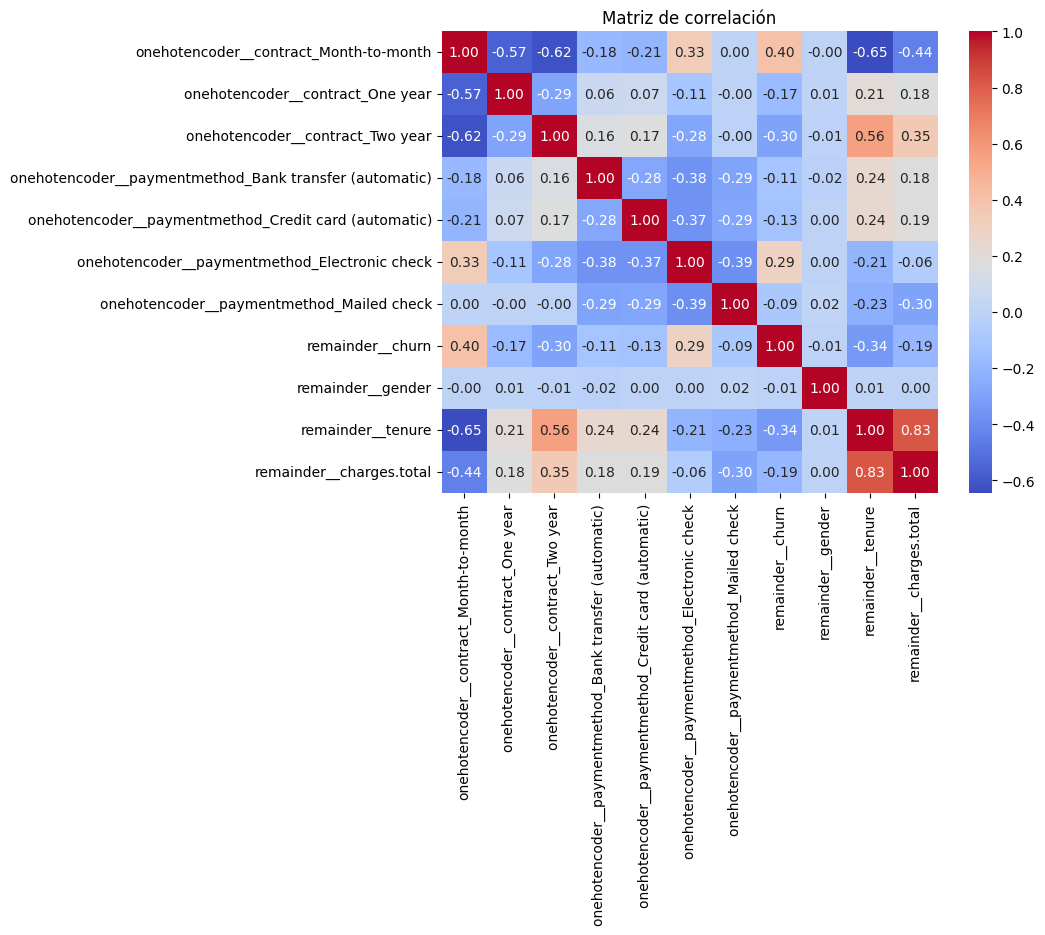

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

**¿Cuál modelo tuvo el mejor desempeño?**

El modelo que mejor equilibrio presenta entre aprendizaje y generalización es KNN, mientras que Random Forest muestra un caso claro de sobreajuste, por lo que requeriría ajuste de hiperparámetros para mejorar su capacidad predictiva en datos no vistos.


En este caso, el modelo Random Forest presenta un claro indicio de overfitting, ya que obtuvo:

98.9% de exactitud en entrenamiento

74.8% de exactitud en prueba

La diferencia considerable entre ambas métricas evidencia que el modelo se ajustó demasiado a los datos de entrenamiento.








In [159]:
print("KNN entrenamiento:", modelo_knn.score(X_train_scaled, y_train))
print("KNN prueba:", modelo_knn.score(X_test_scaled, y_test))
print("Random Forest entrenamiento:", modelo_rf.score(X_train, y_train))
print("Random Forest prueba:", modelo_rf.score(X_test, y_test))

KNN entrenamiento: 0.8383798662996461
KNN prueba: 0.7634112792297112
Random Forest entrenamiento: 0.988989382618954
Random Forest prueba: 0.7487391104997707


El modelo KNN no genera una importancia de variables explícita como los modelos basados en árboles. En su lugar, clasifica observando la distancia entre los puntos en el espacio de características.


¿Cómo influyen las variables?

KNN utiliza (normalmente) la distancia euclidiana:

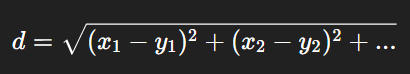





Por lo tanto:

Las variables con mayor variabilidad influyen más en la distancia.
Las variables mejor separadas entre clientes que cancelan y no cancelan impactan más en la decisión.

Si los datos están normalizados, todas las variables contribuyen en la misma escala.

Variables que más influyen en KNN (según la correlación observada)

Basándonos en la matriz de correlación, las variables que probablemente más influyen en la cercanía entre clientes son:

1. contract_Month-to-month

2. tenure

3. contract_Two year

4. paymentmethod_Electronic check

Porque estas variables generan separaciones claras entre clientes que cancelan y los que no, lo que produce agrupamientos naturales en el espacio de características.


En KNN:

Clientes con contrato mensual tienden a estar cerca entre sí.

Clientes con alta antigüedad tienden a agruparse en la clase "No churn".

En el modelo KNN, las variables más relevantes son aquellas que contribuyen significativamente a la distancia entre los puntos de datos. El tipo de contrato y la antigüedad del cliente parecen influir notablemente en la proximidad entre observaciones, facilitando la diferenciación entre clientes que cancelan y aquellos que permanecen.

In [160]:
#MEDIDA DIRECTA DE IMPORTANCIA PARA RANDOM FOREST
modelo_rf.feature_importances_

array([0.08448884, 0.01108437, 0.02295621, 0.00535975, 0.00556362,
       0.03966266, 0.011198  , 0.01621505, 0.24545617, 0.55801533])

Esta importancia se basa en:

Reducción de impureza

Cada vez que una variable:

*   Divide un nodo,
*   Reduce la impureza (Gini o Entropía),


Las variables que:

*   Se usan con mayor frecuencia
*   Generan divisiones más informativas
*   Obtienen mayor importancia.


##**CONCLUSIÓN**


El análisis predictivo realizado mediante los modelos KNN y Random Forest permitió identificar los principales factores que influyen en la cancelación de clientes (churn). A partir de los resultados obtenidos y del análisis de correlación, se concluye que la cancelación no ocurre de manera aleatoria, sino que está fuertemente asociada con variables relacionadas con el nivel de compromiso contractual y la antigüedad del cliente.

El tipo de contrato emerge como el factor más determinante. Los clientes con contratos Month-to-month presentan una mayor probabilidad de cancelar, mientras que aquellos con contratos de uno o dos años muestran una menor tasa de evasión. Esto evidencia que el nivel de compromiso contractual es un elemento protector frente a la cancelación.

La antigüedad del cliente (tenure) también resulta clave: a mayor tiempo de permanencia, menor probabilidad de churn. Esto sugiere que los clientes nuevos representan el segmento más vulnerable y requieren estrategias tempranas de fidelización.

Adicionalmente, el método de pago, especialmente el uso de electronic check, muestra una asociación positiva con la cancelación, lo que podría indicar perfiles de clientes con menor estabilidad o menor vinculación automática con el servicio.


Desde una perspectiva estratégica, los hallazgos permiten proponer las siguientes acciones:

*  Implementar incentivos para migrar clientes de contratos mensuales a contratos de mayor duración.

*  Diseñar programas de fidelización enfocados en los primeros meses del cliente.

*  Ofrecer beneficios o descuentos por adopción de métodos de pago automáticos.

-  Aplicar modelos predictivos periódicos para identificar clientes en riesgo y actuar preventivamente.